# Лабораторная работа №4. Линейные модели, SVM и деревья решений

**Курс:** Технологии машинного обучения

**Цель работы:** изучение линейных моделей, SVM и деревьев решений.

**Задание:**
1. Выбрать набор данных (датасет) для решения задачи классификации или регрессии.
2. В случае необходимости провести удаление или заполнение пропусков и кодирование категориальных признаков.
3. С использованием метода `train_test_split` разделить выборку на обучающую и тестовую.
4. Обучить модели: логистическую регрессию (линейная модель для классификации), SVM, дерево решений.
5. Оценить качество моделей с помощью двух подходящих для задачи метрик и сравнить модели.
6. Построить график важности признаков в дереве решений.
7. Визуализировать дерево решений и вывести его правила в текстовом виде.

Ссылка на постановку задания: https://github.com/ugapanyuk/courses_current/wiki/LAB_TMO_TREES

## 1. Выбор набора данных

Используется датасет **Palmer Archipelago (Antarctica) Penguins** с платформы Kaggle
([parulpandey/palmer-archipelago-antarctica-penguin-data](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data)).
Файл сохранён локально в `data/penguins.csv` (копия из открытого репозитория seaborn-data с теми же данными Palmer Station LTER).

Датасет содержит измерения 344 пингвинов трёх видов. Решается задача **многоклассовой классификации** —
определить вид пингвина (`Adelie`, `Chinstrap`, `Gentoo`) по морфологическим признакам.

Датасет подходит для задания, так как:
- есть **пропуски** (в числовых признаках и в `sex`), которые нужно обработать;
- есть **категориальные признаки** (`island`, `sex`), которые нужно закодировать;
- признаки разного масштаба (граммы и миллиметры), что важно для логистической регрессии и SVM;
- небольшой размер и интерпретируемые признаки позволяют наглядно визуализировать дерево решений.

**Описание столбцов:**
- `species` — вид пингвина (целевой признак);
- `island` — остров наблюдения (Biscoe, Dream, Torgersen) — категориальный;
- `bill_length_mm` — длина клюва (мм);
- `bill_depth_mm` — глубина клюва (мм);
- `flipper_length_mm` — длина плавника (мм);
- `body_mass_g` — масса тела (г);
- `sex` — пол (MALE / FEMALE) — категориальный.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                             confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

## 2. Загрузка данных и первичный анализ

In [2]:
data = pd.read_csv("data/penguins.csv")
print("Размер набора данных:", data.shape)
data.head()

Размер набора данных: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
bill_length_mm,342.0,43.921930,5.459584,32.1,39.225,44.45,48.5,59.6
bill_depth_mm,342.0,17.151170,1.974793,13.1,15.600,17.30,18.7,21.5
flipper_length_mm,342.0,200.915205,14.061714,172.0,190.000,197.00,213.0,231.0
body_mass_g,342.0,4201.754386,801.954536,2700.0,3550.000,4050.00,4750.0,6300.0


Распределение классов:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


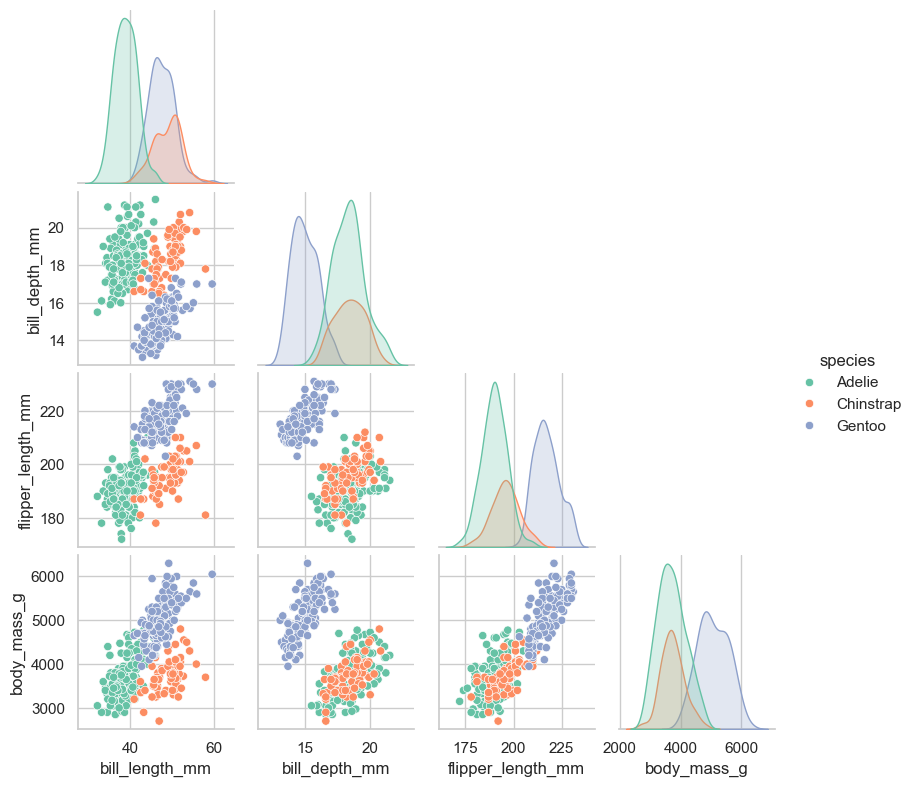

In [5]:
print("Распределение классов:")
print(data["species"].value_counts())

sns.pairplot(data, hue="species", vars=["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"],
             palette="Set2", height=2.0, corner=True)
plt.show()

## 3. Обработка пропусков и кодирование категориальных признаков

In [6]:
missing = pd.DataFrame({"Пропусков": data.isna().sum(),
                        "Доля, %": (data.isna().mean() * 100).round(1)})
missing

,Пропусков,"Доля, %"
species,0,0.0
island,0,0.0
bill_length_mm,2,0.6
bill_depth_mm,2,0.6
flipper_length_mm,2,0.6
body_mass_g,2,0.6
sex,11,3.2


Пропуски есть в четырёх числовых признаках (по 2 строки) и в `sex` (11 строк, ~3 %). Пропусков мало, но выбрасывать строки при
выборке всего в 344 объекта нежелательно, поэтому:
- в числовых признаках пропуски заполняются **медианой**;
- в категориальных (`sex`) — **самым частым значением**;
- категориальные признаки кодируются **One-Hot Encoding**;
- числовые признаки масштабируются `StandardScaler` (нужно для логистической регрессии и SVM; для дерева не обязательно, но не вредит).

Медианы и частоты вычисляются только по обучающей выборке: вся предобработка собрана в `ColumnTransformer`, входящий в `Pipeline`, что исключает утечку данных.
Строки, в которых пропущены все измерения (две записи), сохраняются, так как импьютер заполняет их по обучающей выборке.

In [7]:
# на всякий случай проверим уникальные значения категориальных признаков
for col in ["island", "sex"]:
    print(col, "->", data[col].unique())

island -> ['Torgersen' 'Biscoe' 'Dream']
sex -> ['MALE' 'FEMALE' nan]


## 4. Разделение выборки на обучающую и тестовую

In [8]:
X = data.drop(columns="species")
y = data["species"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y)

print("Обучающая выборка:", X_train.shape, " Тестовая выборка:", X_test.shape)
print("\nДоли классов в обучающей выборке:\n", y_train.value_counts(normalize=True).round(3))
print("\nДоли классов в тестовой выборке:\n", y_test.value_counts(normalize=True).round(3))

Обучающая выборка: (258, 6)  Тестовая выборка: (86, 6)

Доли классов в обучающей выборке:
 species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.198
Name: proportion, dtype: float64

Доли классов в тестовой выборке:
 species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.198
Name: proportion, dtype: float64


In [9]:
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cat_cols = ["island", "sex"]

preprocess = ColumnTransformer([
    ("num", Pipeline([("imputer", SimpleImputer(strategy="median")),
                      ("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                      ("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols),
])

# Проверим результат предобработки на обучающей выборке
Xt = preprocess.fit_transform(X_train)
feature_names = list(preprocess.get_feature_names_out())
print("Признаки после предобработки:", feature_names)
print("Пропусков после обработки:", int(np.isnan(Xt).sum()))
pd.DataFrame(Xt, columns=feature_names).head()

Признаки после предобработки: ['num__bill_length_mm', 'num__bill_depth_mm', 'num__flipper_length_mm', 'num__body_mass_g', 'cat__island_Biscoe', 'cat__island_Dream', 'cat__island_Torgersen', 'cat__sex_FEMALE', 'cat__sex_MALE']
Пропусков после обработки: 0


,num__bill_length_mm,num__bill_depth_mm,num__flipper_length_mm,num__body_mass_g,cat__island_Biscoe,cat__island_Dream,cat__island_Torgersen,cat__sex_FEMALE,cat__sex_MALE
0,0.413886,-0.776452,1.448985,0.983635,1.0,0.0,0.0,0.0,1.0
1,-1.238982,-0.180248,-0.637888,-1.522503,0.0,1.0,0.0,1.0,0.0
2,1.412872,1.161212,0.369568,-0.332088,0.0,1.0,0.0,0.0,1.0
3,-0.821224,0.813426,-0.781811,0.482407,0.0,1.0,0.0,0.0,1.0
4,-1.438779,-0.528033,-0.997694,-0.833315,0.0,0.0,1.0,1.0,0.0


## 5. Обучение моделей

Обучаются три модели (каждая в составе `Pipeline` с общей предобработкой):
1. **Логистическая регрессия** (`LogisticRegression`) — линейная модель классификации;
2. **SVM** (`SVC` с RBF-ядром);
3. **Дерево решений** (`DecisionTreeClassifier`, `max_depth=4` — ограничение глубины для читаемости и защиты от переобучения).

In [10]:
models = {
    "Логистическая регрессия": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, random_state=RANDOM_STATE),
    "Дерево решений": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
}

fitted = {}
for name, est in models.items():
    fitted[name] = Pipeline([("prep", preprocess), ("model", est)]).fit(X_train, y_train)
    print("Обучена модель:", name)

Обучена модель: Логистическая регрессия
Обучена модель: SVM (RBF)
Обучена модель: Дерево решений


## 6. Оценка качества и сравнение моделей

Задача многоклассовая, классы умеренно несбалансированы (Adelie ~44 %, Gentoo ~36 %, Chinstrap ~20 %), поэтому используются две метрики:
- **Accuracy** — доля верных ответов;
- **F1-macro** — среднее F1 по классам (одинаково учитывает редкий класс Chinstrap).

Дополнительно приведены macro-precision и macro-recall, а также 5-кратная кросс-валидация на обучающей выборке для оценки устойчивости.

In [11]:
rows = []
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model in fitted.items():
    pred = model.predict(X_test)
    cv_acc = cross_val_score(Pipeline([("prep", preprocess), ("model", models[name])]),
                             X_train, y_train, cv=cv, scoring="accuracy")
    rows.append({
        "Модель": name,
        "Accuracy": accuracy_score(y_test, pred),
        "F1-macro": f1_score(y_test, pred, average="macro"),
        "Precision-macro": precision_score(y_test, pred, average="macro"),
        "Recall-macro": recall_score(y_test, pred, average="macro"),
        "CV Accuracy (train, 5 fold)": cv_acc.mean(),
    })
results = pd.DataFrame(rows).set_index("Модель")
results.round(4)

,Accuracy,F1-macro,Precision-macro,Recall-macro,"CV Accuracy (train, 5 fold)"
Модель,,,,,
Логистическая регрессия,1.0000,1.0000,1.0000,1.0000,0.9922
SVM (RBF),1.0000,1.0000,1.0000,1.0000,0.9884
Дерево решений,0.9884,0.9903,0.9896,0.9912,0.9728


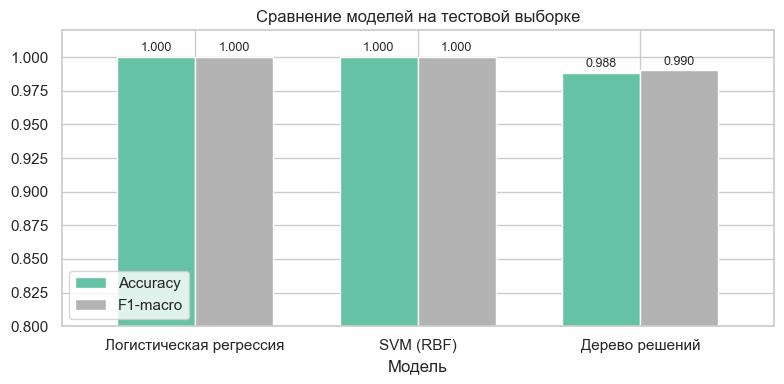

In [12]:
ax = results[["Accuracy", "F1-macro"]].plot(kind="bar", figsize=(8, 4), rot=0, colormap="Set2", width=0.7)
ax.set_ylim(0.8, 1.02)
ax.set_title("Сравнение моделей на тестовой выборке")
for c in ax.containers:
    ax.bar_label(c, fmt="%.3f", fontsize=9, padding=2)
plt.tight_layout()
plt.show()

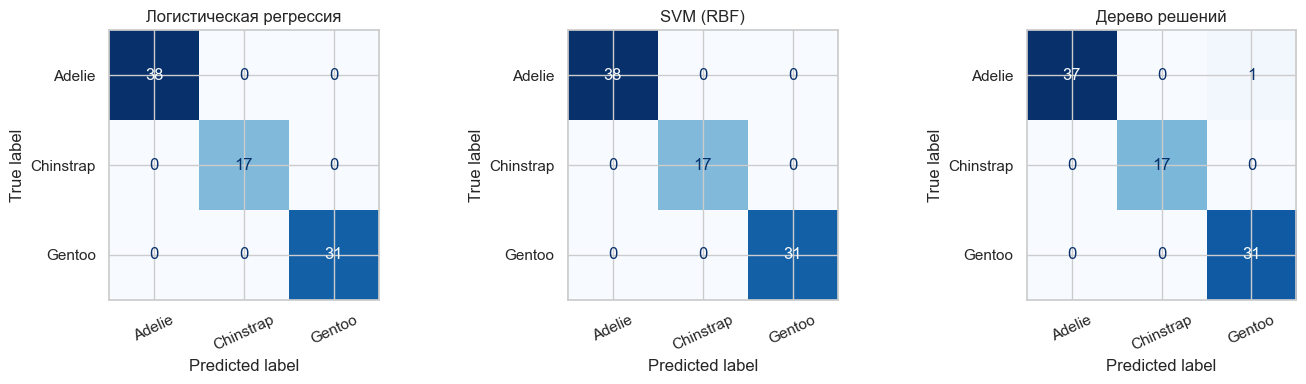

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, model) in zip(axes, fitted.items()):
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues", ax=ax, colorbar=False)
    ax.set_title(name)
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

In [14]:
for name, model in fitted.items():
    print("=" * 60)
    print(name)
    print(classification_report(y_test, model.predict(X_test), digits=3))

Логистическая регрессия
              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        38
   Chinstrap      1.000     1.000     1.000        17
      Gentoo      1.000     1.000     1.000        31

    accuracy                          1.000        86
   macro avg      1.000     1.000     1.000        86
weighted avg      1.000     1.000     1.000        86

SVM (RBF)
              precision    recall  f1-score   support

      Adelie      1.000     1.000     1.000        38
   Chinstrap      1.000     1.000     1.000        17
      Gentoo      1.000     1.000     1.000        31

    accuracy                          1.000        86
   macro avg      1.000     1.000     1.000        86
weighted avg      1.000     1.000     1.000        86

Дерево решений
              precision    recall  f1-score   support

      Adelie      1.000     0.974     0.987        38
   Chinstrap      1.000     1.000     1.000        17
      Gentoo      0.969   

## 7. Важность признаков в дереве решений

flipper_length_mm    0.5243
bill_length_mm       0.3366
island_Dream         0.0973
sex_FEMALE           0.0311
body_mass_g          0.0093
bill_depth_mm        0.0014
island_Biscoe        0.0000
island_Torgersen     0.0000
sex_MALE             0.0000
dtype: float64


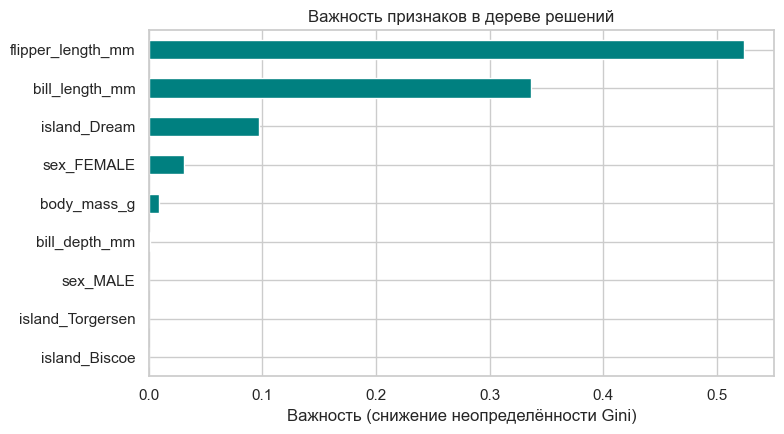

In [15]:
tree_model = fitted["Дерево решений"].named_steps["model"]
importances = pd.Series(tree_model.feature_importances_, index=feature_names).sort_values()
importances.index = [n.split("__", 1)[1] for n in importances.index]

print(importances.sort_values(ascending=False).round(4))

fig, ax = plt.subplots(figsize=(8, 4.5))
importances.plot(kind="barh", color="teal", ax=ax)
ax.set_title("Важность признаков в дереве решений")
ax.set_xlabel("Важность (снижение неопределённости Gini)")
plt.tight_layout()
plt.show()

## 8. Визуализация дерева решений и правила в текстовом виде

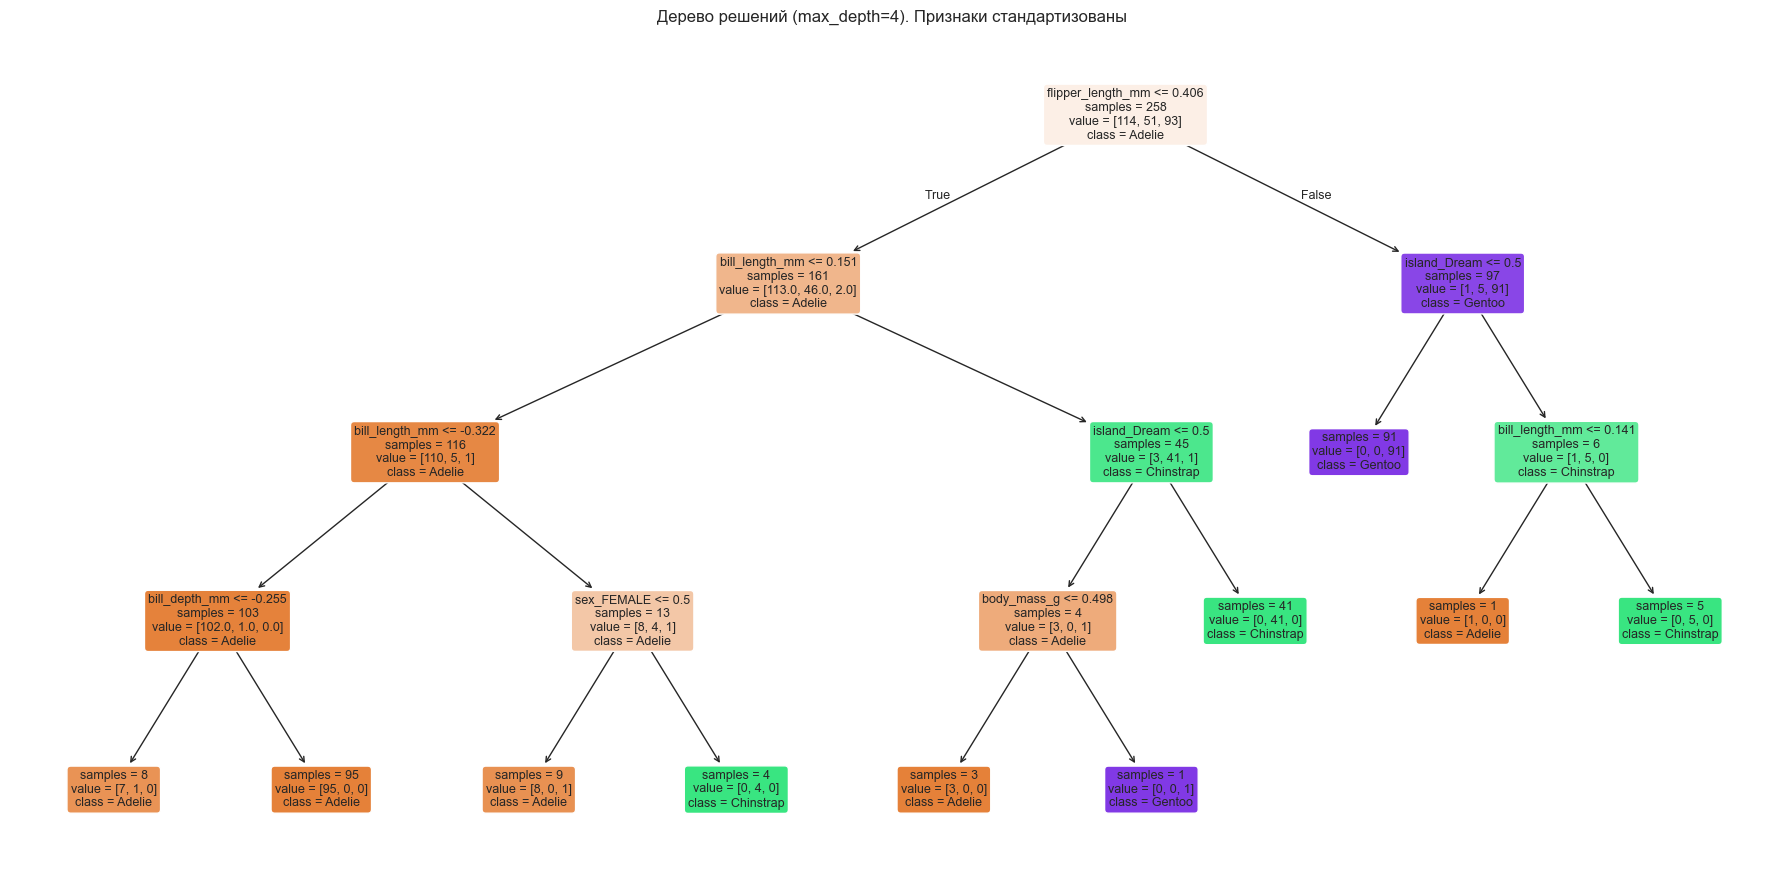

In [16]:
short_names = [n.split("__", 1)[1] for n in feature_names]

fig, ax = plt.subplots(figsize=(18, 9))
plot_tree(tree_model, feature_names=short_names, class_names=list(tree_model.classes_),
          filled=True, rounded=True, fontsize=9, impurity=False, ax=ax)
ax.set_title("Дерево решений (max_depth=4). Признаки стандартизованы")
plt.tight_layout()
plt.show()

In [17]:
print(export_text(tree_model, feature_names=short_names))

|--- flipper_length_mm <= 0.41
|   |--- bill_length_mm <= 0.15
|   |   |--- bill_length_mm <= -0.32
|   |   |   |--- bill_depth_mm <= -0.25
|   |   |   |   |--- class: Adelie
|   |   |   |--- bill_depth_mm >  -0.25
|   |   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  -0.32
|   |   |   |--- sex_FEMALE <= 0.50
|   |   |   |   |--- class: Adelie
|   |   |   |--- sex_FEMALE >  0.50
|   |   |   |   |--- class: Chinstrap
|   |--- bill_length_mm >  0.15
|   |   |--- island_Dream <= 0.50
|   |   |   |--- body_mass_g <= 0.50
|   |   |   |   |--- class: Adelie
|   |   |   |--- body_mass_g >  0.50
|   |   |   |   |--- class: Gentoo
|   |   |--- island_Dream >  0.50
|   |   |   |--- class: Chinstrap
|--- flipper_length_mm >  0.41
|   |--- island_Dream <= 0.50
|   |   |--- class: Gentoo
|   |--- island_Dream >  0.50
|   |   |--- bill_length_mm <= 0.14
|   |   |   |--- class: Adelie
|   |   |--- bill_length_mm >  0.14
|   |   |   |--- class: Chinstrap



Признаки в дереве стандартизованы (среднее 0, стандартное отклонение 1), поэтому пороги в правилах выражены в единицах стандартного отклонения.
При необходимости их можно перевести в исходные единицы: `x = mean + z · std`.

In [18]:
# Перевод порогов первых разбиений в исходные единицы измерения
scaler = fitted["Дерево решений"].named_steps["prep"].named_transformers_["num"].named_steps["scaler"]
stats = pd.DataFrame({"mean": scaler.mean_, "std": scaler.scale_}, index=num_cols)

t = tree_model.tree_
rows = []
for node in range(t.node_count):
    if t.children_left[node] != -1:
        fname = short_names[t.feature[node]]
        thr = t.threshold[node]
        if fname in stats.index:
            rows.append({"Узел": node, "Признак": fname, "Порог (z)": round(thr, 3),
                         "Порог (исходные ед.)": round(stats.loc[fname, "mean"] + thr * stats.loc[fname, "std"], 2)})
        else:
            rows.append({"Узел": node, "Признак": fname, "Порог (z)": round(thr, 3), "Порог (исходные ед.)": "категория (0/1)"})
pd.DataFrame(rows)

,Узел,Признак,Порог (z),Порог (исходные ед.)
0,0,flipper_length_mm,0.406,206.5
1,1,bill_length_mm,0.151,44.95
2,2,bill_length_mm,-0.322,42.35
3,3,bill_depth_mm,-0.255,16.65
4,6,sex_FEMALE,0.500,категория (0/1)
5,9,island_Dream,0.500,категория (0/1)
6,10,body_mass_g,0.498,4612.5
7,14,island_Dream,0.500,категория (0/1)
8,16,bill_length_mm,0.141,44.9


## 9. Выводы

- Выбран датасет Palmer Penguins (Kaggle): многоклассовая классификация вида пингвина. Пропуски (числовые — медиана, `sex` — мода) заполнены, категориальные признаки `island` и `sex` закодированы One-Hot, числовые стандартизованы; вся предобработка внутри `Pipeline`, утечки данных нет.
- Выборка разделена `train_test_split` (75/25, стратификация по виду).
- Обучены логистическая регрессия, SVM (RBF) и дерево решений (`max_depth=4`). Качество оценено по Accuracy и F1-macro.
- На тестовой выборке логистическая регрессия и SVM дали 100 % по обеим метрикам, дерево решений — Accuracy 0.988 и F1-macro 0.990 (1 ошибка из 86). По 5-кратной кросс-валидации на обучающей выборке модели ранжируются так же: логистическая регрессия (0.992) > SVM (0.988) > дерево (0.973).
  Тестовая выборка мала (86 объектов), поэтому различие в один объект несущественно: все три модели решают задачу практически идеально, так как виды хорошо разделяются по размерам плавника и клюва, то есть классы почти линейно разделимы.
- Наиболее важные признаки в дереве: `flipper_length_mm` (0.52) и `bill_length_mm` (0.34), затем `island_Dream` (0.10). Остальные признаки почти не используются. Это согласуется с парными графиками: Gentoo отделяется по длине плавника, а Adelie и Chinstrap — по длине клюва.
- Правила дерева (`export_text`) интерпретируемы: например, если длина плавника > 206.5 мм и остров не Dream, то вид — Gentoo.